# Task 4. Investment strategies for the Spiff markets

This notebook designs, backtests, and ranks investment strategies for the seven Spiff assets: `gurkor`, `guitars`, `slingshots`, `stocks`, `sugar`, `water`, and `tranquillity`.

The analysis is organised in two parts:

1. **Historical backtest on observed data only.** The five all-1000 placeholder rows are replaced by NaN, but the internal 50-day gaps and the trailing 200-day gap are kept as NaN throughout. Interpolated Task 2 values and extrapolated Task 3 values are not treated as realised historical prices.
2. **Forward scenario analysis using Task 3 simulated paths.** The same strategy rules are applied to each Task 3 scenario and the results are clearly labelled as simulated future outcomes, not historical evidence.

The notebook answers eleven questions:

1. What does the cleaned dataset look like?
2. How are returns defined and why?
3. What utility functions are needed for a leakage-free backtest?
4. What is the chronological train/test split?
5. What strategies are implemented and how are parameters chosen?
6. What does full-sample historical performance look like?
7. Does performance hold up out-of-sample?
8. Are parameters stable under walk-forward re-estimation?
9. Are pairs-trading signals consistent with mean reversion?
10. What is the bootstrap uncertainty around each Sharpe ratio?
11. What is the production recommendation, and how do strategies perform on Task 3 scenarios?

In [2]:
from pathlib import Path
import sys
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

try:
    from statsmodels.tsa.stattools import adfuller
except Exception:
    adfuller = None

warnings.filterwarnings("ignore")

repo_root = Path.cwd()
if not (repo_root / "Data").exists():
    repo_root = repo_root.parent

sys.path.append(str(repo_root))
from config.plot_config import plot_config
plot_config()

ASSETS = ["gurkor", "guitars", "slingshots", "stocks", "sugar", "water", "tranquillity"]
PAIRS = [("gurkor", "water"), ("guitars", "slingshots")]
TRADING_DAYS = 252
ANNUAL_RF = 0.03
DAILY_RF = (1 + ANNUAL_RF) ** (1 / TRADING_DAYS) - 1
BOOTSTRAP_SAMPLES = 1000
RNG_SEED = 2026

fig_dir = repo_root / "Figures" / "figs"
table_dir = repo_root / "Figures" / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

STRATEGY_LABELS = {
    "equal_weight_bh": "Equal-weight buy-and-hold",
    "inverse_vol": "Inverse-volatility",
    "ma_crossover": "Moving-average crossover",
    "rsi_reversion": "RSI mean-reversion",
    "bollinger_reversion": "Bollinger mean-reversion",
    "pairs_gurkor_water": "Pairs: gurkor-water",
    "pairs_guitars_slingshots": "Pairs: guitars-slingshots",
    "pairs_combined": "Combined pairs",
    "min_variance": "Minimum-variance",
    "ma_crossover_opt": "Optimized MA crossover",
    "rsi_reversion_opt": "Optimized RSI mean-reversion",
    "bollinger_reversion_opt": "Optimized Bollinger mean-reversion",
    "pairs_gurkor_water_opt": "Optimized pairs: gurkor-water",
    "pairs_guitars_slingshots_opt": "Optimized pairs: guitars-slingshots",
    "pairs_combined_opt": "Optimized combined pairs",
}


def _latex_escape(value) -> str:
    text = str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def write_latex_table(df: pd.DataFrame, path: Path, float_format: str = "%.4f", index: bool = True) -> None:
    table = df.reset_index() if index else df.copy()
    columns = [str(col) for col in table.columns]

    def fmt(value):
        if pd.isna(value):
            return ""
        if isinstance(value, (float, np.floating)):
            return float_format % value
        return _latex_escape(value)

    lines = [
        r"\begin{tabular}{" + "l" * len(columns) + "}",
        r"\toprule",
        " & ".join(_latex_escape(col) for col in columns) + r" \\",
        r"\midrule",
    ]
    for _, row in table.iterrows():
        lines.append(" & ".join(fmt(row[col]) for col in table.columns) + r" \\")
    lines.extend([r"\bottomrule", r"\end{tabular}"])
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

## 1. Load and clean data

The five rows where all seven assets equal `1000` are treated as implausible placeholders and replaced by `NaN`. Internal missing gaps and the final 200 missing observations remain `NaN` throughout the historical backtest. This matters because interpolation and extrapolation are modelling outputs, not realized market prices.

In [3]:
raw = pd.read_csv(repo_root / "Data" / "spiff_data-2.csv")
prices = raw.drop(columns=["Unnamed: 0"], errors="ignore").set_index("day")
prices = prices[ASSETS].astype(float)
placeholder_mask = (prices == 1000).all(axis=1)
prices.loc[placeholder_mask, ASSETS] = np.nan


def final_missing_mask(data: pd.DataFrame) -> pd.DataFrame:
    mask = pd.DataFrame(False, index=data.index, columns=data.columns)
    for asset in data.columns:
        missing = data[asset].isna().to_numpy()
        if not missing[-1]:
            continue
        start = len(missing) - 1
        while start > 0 and missing[start - 1]:
            start -= 1
        mask.loc[data.index[start:], asset] = True
    return mask

final_mask = final_missing_mask(prices)
internal_mask = prices.isna() & ~final_mask

summary = []
for asset in ASSETS:
    obs_idx = prices.index[prices[asset].notna()]
    summary.append({
        "asset": asset,
        "observed_prices": int(prices[asset].notna().sum()),
        "missing_prices": int(prices[asset].isna().sum()),
        "internal_missing_values": int(internal_mask[asset].sum()),
        "final_missing_values": int(final_mask[asset].sum()),
        "first_observed_day": int(obs_idx.min()),
        "last_observed_day": int(obs_idx.max()),
    })

data_summary = pd.DataFrame(summary).set_index("asset")
write_latex_table(data_summary, table_dir / "task4_validation_data_summary.tex", float_format="%.0f")
print(f"Rows replaced because all assets equal 1000: {int(placeholder_mask.sum())}")
data_summary

Rows replaced because all assets equal 1000: 5


,observed_prices,missing_prices,internal_missing_values,final_missing_values,first_observed_day,last_observed_day
asset,,,,,,
gurkor,5201,255,55,200,1,5256
guitars,5201,255,55,200,1,5256
slingshots,5201,255,55,200,1,5256
stocks,5201,255,55,200,1,5256
sugar,5201,255,55,200,1,5256
water,5201,255,55,200,1,5256
tranquillity,5201,255,55,200,1,5256


## 2. Returns

Log returns are used for signal construction because they are additive over time and align with the earlier time-series analysis. Simple returns are used for portfolio accounting because wealth evolves multiplicatively through \(1+r_t\). `pct_change(fill_method=None)` is used so pandas does not silently forward-fill prices before computing returns.

In [4]:
log_prices = np.log(prices)
log_returns = log_prices.diff()
simple_returns = prices.pct_change(fill_method=None)

returns_summary = pd.DataFrame({
    "observed_simple_returns": simple_returns.notna().sum(),
    "missing_simple_returns": simple_returns.isna().sum(),
    "mean_log_return": log_returns.mean(),
    "std_log_return": log_returns.std(),
})
write_latex_table(returns_summary, table_dir / "task4_validation_return_summary.tex", float_format="%.5f")
returns_summary

,observed_simple_returns,missing_simple_returns,mean_log_return,std_log_return
gurkor,5194,262,0.000155,0.003945
guitars,5194,262,0.000236,0.014876
slingshots,5194,262,0.000194,0.014747
stocks,5194,262,-0.000074,0.014935
sugar,5194,262,-0.000014,0.015209
water,5194,262,0.000152,0.003515
tranquillity,5194,262,0.000078,0.012589


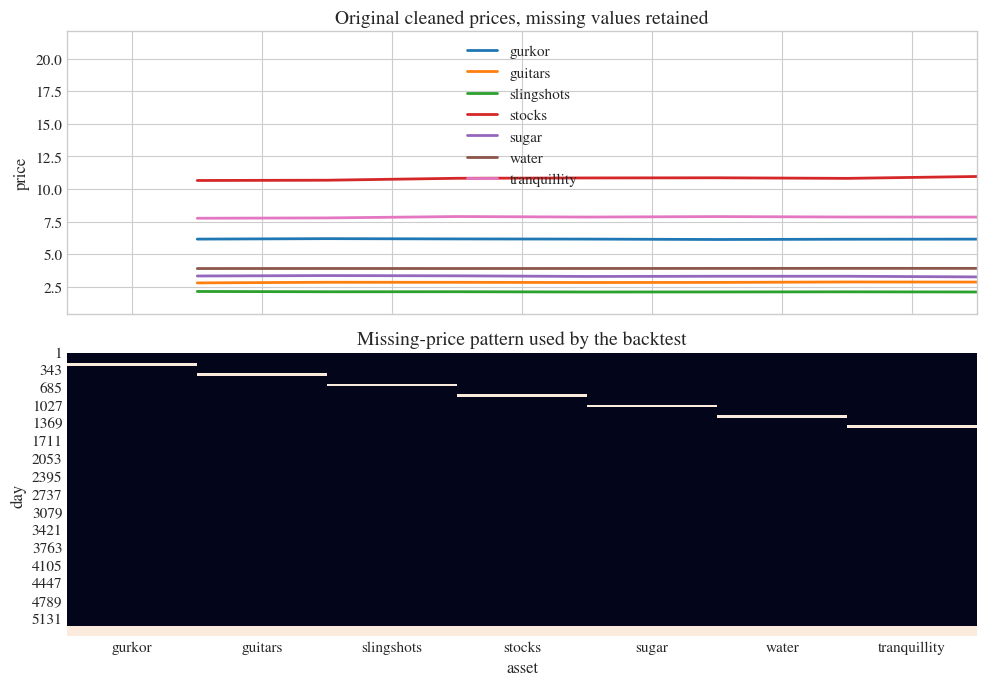

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
prices.plot(ax=axes[0])
axes[0].set_title("Original cleaned prices, missing values retained")
axes[0].set_ylabel("price")

sns.heatmap(prices.isna(), cbar=False, ax=axes[1])
axes[1].set_title("Missing-price pattern used by the backtest")
axes[1].set_xlabel("asset")
axes[1].set_ylabel("day")
fig.tight_layout()
fig.savefig(fig_dir / "task4_validation_prices_missingness.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Utility functions

Signals are lagged by one day because a signal computed at the close of day \(t-1\) can only be applied to the return from \(t-1\) to \(t\). If a strategy holds an asset whose realized return is missing on day \(t\), the strategy return for day \(t\) is set to `NaN` and excluded from performance metrics.

Sharpe ratio is useful but incomplete: it summarizes average excess return per unit of volatility, but it does not show path risk, tail losses, turnover, or parameter instability. Max drawdown is reported because it measures the largest peak-to-trough wealth loss experienced by the strategy.

In [6]:
def annualized_return(returns: pd.Series, trading_days: int = TRADING_DAYS) -> float:
    clean = returns.dropna()
    if len(clean) == 0:
        return np.nan
    total = (1 + clean).prod() - 1
    years = len(clean) / trading_days
    return (1 + total) ** (1 / years) - 1 if years > 0 and (1 + total) > 0 else np.nan


def annualized_volatility(returns: pd.Series, trading_days: int = TRADING_DAYS) -> float:
    clean = returns.dropna()
    return clean.std(ddof=1) * np.sqrt(trading_days) if len(clean) > 1 else np.nan


def sharpe_ratio(returns: pd.Series, annual_rf: float = ANNUAL_RF, trading_days: int = TRADING_DAYS) -> float:
    clean = returns.dropna()
    if len(clean) < 2:
        return np.nan
    daily_rf = (1 + annual_rf) ** (1 / trading_days) - 1
    excess = clean - daily_rf
    return excess.mean() / excess.std(ddof=1) * np.sqrt(trading_days) if excess.std(ddof=1) > 0 else np.nan


def cumulative_wealth(returns: pd.Series, initial: float = 1.0) -> pd.Series:
    return (1 + returns.dropna()).cumprod() * initial


def max_drawdown(returns: pd.Series) -> float:
    wealth = cumulative_wealth(returns)
    if wealth.empty:
        return np.nan
    return (wealth / wealth.cummax() - 1).min()


def hit_rate(returns: pd.Series) -> float:
    clean = returns.dropna()
    return (clean > 0).mean() if len(clean) else np.nan


def positions_from_target_weights(target_weights: pd.DataFrame) -> pd.DataFrame:
    positions = target_weights.shift(1).ffill()
    return positions.fillna(0.0)


def strategy_turnover(target_weights: pd.DataFrame) -> float:
    positions = positions_from_target_weights(target_weights)
    return positions.diff().abs().sum(axis=1).mean()


def portfolio_returns(target_weights: pd.DataFrame, asset_returns: pd.DataFrame) -> pd.Series:
    target_weights = target_weights.reindex(asset_returns.index)
    positions = positions_from_target_weights(target_weights)
    risky = (positions * asset_returns).sum(axis=1, min_count=1)
    held_missing = (positions.abs() > 1e-12) & asset_returns.isna()
    invalid = held_missing.any(axis=1)
    gross_exposure = positions.abs().sum(axis=1)
    cash_weight = (1 - gross_exposure).clip(lower=0)
    out = risky + cash_weight * DAILY_RF
    out[invalid] = np.nan
    return out


def performance_table(strategy_returns: pd.DataFrame, weights: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name in strategy_returns.columns:
        r = strategy_returns[name]
        rows.append({
            "strategy": STRATEGY_LABELS.get(name, name),
            "observed_days": int(r.notna().sum()),
            "annual_return": annualized_return(r),
            "annual_volatility": annualized_volatility(r),
            "sharpe": sharpe_ratio(r),
            "max_drawdown": max_drawdown(r),
            "hit_rate": hit_rate(r),
            "turnover": strategy_turnover(weights[name]),
            "mean_gross_exposure": positions_from_target_weights(weights[name]).abs().sum(axis=1).mean(),
        })
    return pd.DataFrame(rows).set_index("strategy").sort_values("sharpe", ascending=False)

## 4. Train/test split

The split is chronological and uses only the observed historical part of the dataset. In-sample performance is used for calibration and diagnostics; out-of-sample performance is the more relevant evidence for production credibility. This separation reduces the risk of choosing a strategy because it happened to fit one historical period unusually well.

In [7]:
last_any_observed_day = int(prices.dropna(how="all").index.max())
historical_index = simple_returns.loc[:last_any_observed_day].index
split_pos = int(0.7 * len(historical_index))
split_day = int(historical_index[split_pos])
train_index = historical_index[historical_index < split_day]
test_index = historical_index[historical_index >= split_day]
print(f"Historical sample ends at day {last_any_observed_day}.")
print(f"Train period: {int(train_index.min())}-{int(train_index.max())}, test period: {int(test_index.min())}-{int(test_index.max())}.")

Historical sample ends at day 5256.
Train period: 1-3679, test period: 3680-5256.


## 5. Strategy definitions

The strategy set combines passive allocation, risk-based allocation, trend following, mean reversion, pairs trading, and minimum-variance portfolio construction.

**Passive and risk-based strategies** make no directional prediction and serve as benchmarks. Equal-weight buy-and-hold is the simplest baseline; inverse-volatility and minimum-variance exploit the large differences in return variance across the seven assets documented in Task 1.

**Trend and mean-reversion strategies** (MA crossover, RSI, Bollinger) exploit directional persistence or short-horizon reversals in individual price series.

**Pairs trading** is motivated by the Task 1 grouping evidence: `gurkor` and `water` have a log-return correlation of about 0.57, and `guitars` and `slingshots` about 0.53. A spread-based strategy is plausible if the spread is mean-reverting, but this must be confirmed out-of-sample rather than assumed from Task 1 correlations alone.

**Optimised variants** tune indicator parameters on the train period only, apply those fixed parameters on the test period, and use signals lagged by one day throughout.

In [8]:
def safe_normalize_long_only(raw: pd.DataFrame) -> pd.DataFrame:
    out = raw.clip(lower=0).astype(float)
    row_sum = out.sum(axis=1)
    return out.div(row_sum.replace(0, np.nan), axis=0)


def equal_weight_buy_hold(returns: pd.DataFrame) -> pd.DataFrame:
    weights = pd.DataFrame(np.nan, index=returns.index, columns=ASSETS)
    current = pd.Series(1 / len(ASSETS), index=ASSETS, dtype=float)
    for day in returns.index:
        weights.loc[day] = current
        r = returns.loc[day]
        if r.notna().all():
            updated = current * (1 + r)
            current = updated / updated.sum()
    return weights


def inverse_volatility(returns_log: pd.DataFrame, window: int = 126, rebalance_every: int = 21) -> pd.DataFrame:
    vol = returns_log.rolling(window, min_periods=window).std()
    weights = pd.DataFrame(np.nan, index=returns_log.index, columns=ASSETS)
    current = pd.Series(1 / len(ASSETS), index=ASSETS, dtype=float)
    for i, day in enumerate(returns_log.index):
        if i % rebalance_every == 0:
            v = vol.loc[day]
            if v.notna().all() and (v > 0).all():
                inv = 1 / v
                current = inv / inv.sum()
            else:
                current = pd.Series(1 / len(ASSETS), index=ASSETS, dtype=float)
        weights.loc[day] = current
    return weights


def moving_average_crossover(price_data: pd.DataFrame, fast: int = 20, slow: int = 100) -> pd.DataFrame:
    fast_ma = price_data.rolling(fast, min_periods=fast).mean()
    slow_ma = price_data.rolling(slow, min_periods=slow).mean()
    raw = (fast_ma > slow_ma).where(fast_ma.notna() & slow_ma.notna()).astype(float)
    return safe_normalize_long_only(raw)


def compute_rsi(price_data: pd.DataFrame, window: int = 14) -> pd.DataFrame:
    """Wilder-style RSI using exponentially weighted average gains/losses."""
    delta = price_data.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - 100 / (1 + rs)
    return rsi.where(avg_loss > 0, 100.0)


def rsi_mean_reversion(price_data: pd.DataFrame, window: int = 14, entry: float = 30, exit_threshold: float = 50) -> pd.DataFrame:
    rsi = compute_rsi(price_data, window)
    signal = pd.DataFrame(np.nan, index=price_data.index, columns=ASSETS)
    state = pd.Series(False, index=ASSETS)
    for day in price_data.index:
        row = rsi.loc[day]
        for asset in ASSETS:
            if pd.isna(row[asset]):
                continue
            if not state[asset] and row[asset] < entry:
                state[asset] = True
            elif state[asset] and row[asset] > exit_threshold:
                state[asset] = False
        signal.loc[day] = state.astype(float)
    return safe_normalize_long_only(signal)


def bollinger_mean_reversion(price_data: pd.DataFrame, window: int = 50, multiplier: float = 2.0) -> pd.DataFrame:
    mean = price_data.rolling(window, min_periods=window).mean()
    std = price_data.rolling(window, min_periods=window).std()
    lower = mean - multiplier * std
    signal = pd.DataFrame(np.nan, index=price_data.index, columns=ASSETS)
    state = pd.Series(False, index=ASSETS)
    for day in price_data.index:
        for asset in ASSETS:
            p, m, lo = price_data.loc[day, asset], mean.loc[day, asset], lower.loc[day, asset]
            if pd.isna(p) or pd.isna(m) or pd.isna(lo):
                continue
            if not state[asset] and p < lo:
                state[asset] = True
            elif state[asset] and p > m:
                state[asset] = False
        signal.loc[day] = state.astype(float)
    return safe_normalize_long_only(signal)


def rolling_beta(log_a: pd.Series, log_b: pd.Series, window: int) -> pd.Series:
    cov = log_a.rolling(window, min_periods=window).cov(log_b)
    var = log_b.rolling(window, min_periods=window).var()
    return cov / var.replace(0, np.nan)


def pairs_trading_weights(log_price_data: pd.DataFrame, pair: tuple[str, str], window: int = 126, entry_z: float = 2.0, exit_z: float = 0.5) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    a, b = pair
    beta = rolling_beta(log_price_data[a], log_price_data[b], window)
    spread = log_price_data[a] - beta * log_price_data[b]
    mean = spread.rolling(window, min_periods=window).mean()
    std = spread.rolling(window, min_periods=window).std()
    z = (spread - mean) / std.replace(0, np.nan)

    weights = pd.DataFrame(0.0, index=log_price_data.index, columns=ASSETS)
    state = 0
    for day in log_price_data.index:
        zi, bi = z.loc[day], beta.loc[day]
        if pd.isna(zi) or pd.isna(bi):
            weights.loc[day] = np.nan
            continue
        if state == 0 and zi < -entry_z:
            state = 1
        elif state == 0 and zi > entry_z:
            state = -1
        elif state != 0 and abs(zi) < exit_z:
            state = 0
        w = pd.Series(0.0, index=ASSETS)
        if state != 0:
            raw_a = state
            raw_b = -state * bi
            gross = abs(raw_a) + abs(raw_b)
            w[a] = raw_a / gross
            w[b] = raw_b / gross
        weights.loc[day] = w
    return weights, spread, z


def minimum_variance(price_returns: pd.DataFrame, window: int = 252, rebalance_every: int = 21) -> pd.DataFrame:
    weights = pd.DataFrame(np.nan, index=price_returns.index, columns=ASSETS)
    current = pd.Series(1 / len(ASSETS), index=ASSETS, dtype=float)
    bounds = [(0.0, 1.0)] * len(ASSETS)
    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1})
    for i, day in enumerate(price_returns.index):
        if i % rebalance_every == 0:
            window_returns = price_returns.loc[:day].tail(window)
            if len(window_returns) == window and window_returns.notna().all().all():
                cov = window_returns.cov().to_numpy()
                x0 = current.to_numpy()
                res = minimize(lambda w: float(w @ cov @ w), x0, bounds=bounds, constraints=constraints, method="SLSQP")
                if res.success and np.isfinite(res.x).all():
                    current = pd.Series(res.x, index=ASSETS)
                else:
                    current = inverse_volatility(log_returns.loc[:day].tail(window), window=min(126, window)).ffill().tail(1).squeeze()
            else:
                current = pd.Series(1 / len(ASSETS), index=ASSETS, dtype=float)
        weights.loc[day] = current
    return weights

### Train-period parameter optimization

The reference notebook tunes indicator parameters before evaluating out of sample. We add the same idea here, but keep the validation discipline stricter: parameters are selected on the train period only, signals are still lagged, and missing realized returns remain excluded. MA, RSI, and Bollinger are tuned per asset because the seven series have different volatility and trend behaviour. Pairs strategies are tuned at the pair portfolio level.

In [ ]:
# from the default strategy specifications.
OPT_MA_GRID = [
    {"fast": f, "slow": s}
    for f in [10, 15, 20, 30, 50]
    for s in [50, 80, 100, 150, 200, 252]
    if f < s
]
OPT_RSI_GRID = [
    {"window": w, "entry": entry, "exit_threshold": exit_threshold}
    for w in [7, 10, 14, 21, 50]
    for entry in [20, 25, 30, 35]
    for exit_threshold in [50, 60, 70]
    if entry < exit_threshold
]
OPT_BOLL_GRID = [
    {"window": w, "multiplier": m}
    for w in [10, 20, 30, 50, 100]
    for m in [1.0, 1.5, 2.0, 2.5, 3.0]
]
OPT_PAIR_GRID = [
    {"window": w, "entry_z": e, "exit_z": x}
    for w in [60, 90, 126, 180, 252]
    for e in [1.5, 2.0, 2.5]
    for x in [0.25, 0.5, 1.0]
    if x < e
]


def ma_asset_signal(asset: str, fast: int, slow: int) -> pd.Series:
    fast = int(fast)
    slow = int(slow)
    fast_ma = prices[asset].rolling(fast, min_periods=fast).mean()
    slow_ma = prices[asset].rolling(slow, min_periods=slow).mean()
    return (fast_ma > slow_ma).where(fast_ma.notna() & slow_ma.notna()).astype(float)


def rsi_asset_signal(asset: str, window: int, entry: float, exit_threshold: float) -> pd.Series:
    window = int(window)
    rsi = compute_rsi(prices[[asset]], window=window)[asset]
    state = False
    signal = pd.Series(np.nan, index=prices.index, dtype=float)
    for day, value in rsi.items():
        if pd.isna(value):
            continue
        if not state and value < entry:
            state = True
        elif state and value > exit_threshold:
            state = False
        signal.loc[day] = float(state)
    return signal


def bollinger_asset_signal(asset: str, window: int, multiplier: float) -> pd.Series:
    window = int(window)
    p_asset = prices[asset]
    mean = p_asset.rolling(window, min_periods=window).mean()
    std = p_asset.rolling(window, min_periods=window).std()
    lower = mean - multiplier * std
    # Patient exit inspired by task4-Petter: exit when price reaches the upper band.
    upper = mean + multiplier * std
    state = False
    signal = pd.Series(np.nan, index=prices.index, dtype=float)
    for day in prices.index:
        value, lo, hi = p_asset.loc[day], lower.loc[day], upper.loc[day]
        if pd.isna(value) or pd.isna(lo) or pd.isna(hi):
            continue
        if not state and value <= lo:
            state = True
        elif state and value >= hi:
            state = False
        signal.loc[day] = float(state)
    return signal


def single_asset_signal_return(signal: pd.Series, asset: str, idx: pd.Index) -> pd.Series:
    pos = signal.shift(1).ffill().fillna(0.0).reindex(idx)
    ret = simple_returns[asset].reindex(idx)
    out = pos * ret + (1 - pos.abs()) * DAILY_RF
    out[(pos.abs() > 1e-12) & ret.isna()] = np.nan
    return out


def optimize_per_asset(strategy_name: str, grid: list[dict]) -> dict[str, dict]:
    best = {}
    for asset in ASSETS:
        rows = []
        for params in grid:
            if strategy_name == "ma":
                signal = ma_asset_signal(asset, **params)
            elif strategy_name == "rsi":
                signal = rsi_asset_signal(asset, **params)
            elif strategy_name == "bollinger":
                signal = bollinger_asset_signal(asset, **params)
            else:
                raise ValueError(strategy_name)
            r = single_asset_signal_return(signal, asset, train_index)
            rows.append({**params, "sharpe": sharpe_ratio(r), "observed_days": int(r.notna().sum())})
        result = pd.DataFrame(rows).sort_values("sharpe", ascending=False)
        best[asset] = {k: result.iloc[0][k] for k in grid[0].keys()}
    return best


def build_optimized_long_only(strategy_name: str, params_by_asset: dict[str, dict]) -> pd.DataFrame:
    raw = pd.DataFrame(np.nan, index=prices.index, columns=ASSETS)
    for asset, params in params_by_asset.items():
        if strategy_name == "ma":
            raw[asset] = ma_asset_signal(asset, **params)
        elif strategy_name == "rsi":
            raw[asset] = rsi_asset_signal(asset, **params)
        elif strategy_name == "bollinger":
            raw[asset] = bollinger_asset_signal(asset, **params)
    # Carry forward each asset's last valid signal for continuity, then normalize the whole row.
    # This prevents partial row updates from creating gross exposure above 1.
    return safe_normalize_long_only(raw.ffill().fillna(0.0))


def optimize_pair(pair: tuple[str, str], grid: list[dict]) -> tuple[dict, pd.DataFrame, pd.Series, pd.Series, pd.DataFrame]:
    rows = []
    cached = []
    for params in grid:
        clean_params = params.copy()
        clean_params["window"] = int(clean_params["window"])
        w, spread, z = pairs_trading_weights(log_prices, pair, **clean_params)
        r = portfolio_returns(w, simple_returns)
        rows.append({**params, "sharpe": sharpe_ratio(r.reindex(train_index)), "observed_days": int(r.reindex(train_index).notna().sum())})
        cached.append((w, spread, z))
    result = pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)
    best_idx = int(result.index[0])
    best_params = {k: result.loc[best_idx, k] for k in grid[0].keys()}
    if "window" in best_params:
        best_params["window"] = int(best_params["window"])
    w, spread, z = cached[best_idx]
    return best_params, w, spread, z, result


best_ma_per_asset = optimize_per_asset("ma", OPT_MA_GRID)
best_rsi_per_asset = optimize_per_asset("rsi", OPT_RSI_GRID)
best_bollinger_per_asset = optimize_per_asset("bollinger", OPT_BOLL_GRID)

opt_pair_outputs = {}
for pair in PAIRS:
    key = f"pairs_{pair[0]}_{pair[1]}_opt"
    opt_pair_outputs[key] = optimize_pair(pair, OPT_PAIR_GRID)

optimized_parameter_rows = []
for strategy, params_by_asset in [
    ("Optimized MA crossover", best_ma_per_asset),
    ("Optimized RSI mean-reversion", best_rsi_per_asset),
    ("Optimized Bollinger mean-reversion", best_bollinger_per_asset),
]:
    for asset, params in params_by_asset.items():
        optimized_parameter_rows.append({"strategy": strategy, "asset_or_pair": asset, **params})
for key, (params, *_rest) in opt_pair_outputs.items():
    optimized_parameter_rows.append({"strategy": STRATEGY_LABELS[key], "asset_or_pair": key.replace("pairs_", "").replace("_opt", ""), **params})

optimized_parameter_table = pd.DataFrame(optimized_parameter_rows)
write_latex_table(optimized_parameter_table, table_dir / "task4_validation_train_optimized_parameters.tex", float_format="%.4f", index=False)
optimized_parameter_table

,strategy,asset_or_pair,fast,slow,window,entry,exit_threshold,multiplier,entry_z,exit_z
0,Optimized MA crossover,gurkor,50.0,252.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Optimized MA crossover,guitars,30.0,252.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Optimized MA crossover,slingshots,10.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Optimized MA crossover,stocks,50.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Optimized MA crossover,sugar,10.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN
5,Optimized MA crossover,water,15.0,252.0,NaN,NaN,NaN,NaN,NaN,NaN
6,Optimized MA crossover,tranquillity,10.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN
7,Optimized RSI mean-reversion,gurkor,NaN,NaN,14.0,20.0,50.0,NaN,NaN,NaN
8,Optimized RSI mean-reversion,guitars,NaN,NaN,21.0,20.0,60.0,NaN,NaN,NaN
9,Optimized RSI mean-reversion,slingshots,NaN,NaN,50.0,20.0,60.0,NaN,NaN,NaN


In [10]:
def build_main_strategy_weights() -> tuple[dict[str, pd.DataFrame], dict[str, pd.Series], dict[str, pd.Series]]:
    weights = {
        "equal_weight_bh": equal_weight_buy_hold(simple_returns),
        "inverse_vol": inverse_volatility(log_returns, window=126, rebalance_every=21),
        "ma_crossover": moving_average_crossover(prices, fast=20, slow=100),
        "rsi_reversion": rsi_mean_reversion(prices, window=14, entry=30, exit_threshold=50),
        "bollinger_reversion": bollinger_mean_reversion(prices, window=50, multiplier=2.0),
        "min_variance": minimum_variance(simple_returns, window=252, rebalance_every=21),
        "ma_crossover_opt": build_optimized_long_only("ma", best_ma_per_asset),
        "rsi_reversion_opt": build_optimized_long_only("rsi", best_rsi_per_asset),
        "bollinger_reversion_opt": build_optimized_long_only("bollinger", best_bollinger_per_asset),
    }
    spreads = {}
    zscores = {}
    pair_weight_frames = []
    opt_pair_weight_frames = []
    for pair in PAIRS:
        key = f"pairs_{pair[0]}_{pair[1]}"
        w, spread, z = pairs_trading_weights(log_prices, pair, window=126, entry_z=2.0, exit_z=0.5)
        weights[key] = w
        spreads[key] = spread
        zscores[key] = z
        pair_weight_frames.append(w.fillna(0.0))

        opt_key = f"pairs_{pair[0]}_{pair[1]}_opt"
        _params, opt_w, opt_spread, opt_z, _grid = opt_pair_outputs[opt_key]
        weights[opt_key] = opt_w
        spreads[opt_key] = opt_spread
        zscores[opt_key] = opt_z
        opt_pair_weight_frames.append(opt_w.fillna(0.0))

    weights["pairs_combined"] = sum(pair_weight_frames) / len(pair_weight_frames)
    weights["pairs_combined_opt"] = sum(opt_pair_weight_frames) / len(opt_pair_weight_frames)
    return weights, spreads, zscores

main_weights, pair_spreads, pair_zscores = build_main_strategy_weights()
main_returns = pd.DataFrame({name: portfolio_returns(w, simple_returns) for name, w in main_weights.items()})
full_performance = performance_table(main_returns, main_weights)
write_latex_table(full_performance, table_dir / "task4_validation_full_performance.tex", float_format="%.4f")
full_performance

,observed_days,annual_return,annual_volatility,sharpe,max_drawdown,hit_rate,turnover,mean_gross_exposure
strategy,,,,,,,,
Optimized MA crossover,5143,0.106569,0.091235,0.831795,-0.158425,0.551429,0.027220,0.984238
Optimized Bollinger mean-reversion,5041,0.113134,0.142344,0.616562,-0.479930,0.524896,0.052456,0.997251
Moving-average crossover,4990,0.063621,0.093645,0.389904,-0.247605,0.542084,0.035606,0.999026
Inverse-volatility,4888,0.044423,0.061015,0.258446,-0.179900,0.527823,0.003665,0.999817
Minimum-variance,4888,0.043432,0.089204,0.189878,-0.327563,0.525573,0.000183,0.999817
Equal-weight buy-and-hold,4888,0.036927,0.097946,0.117438,-0.372426,0.533552,0.006913,0.999817
Optimized RSI mean-reversion,5245,0.027903,0.185172,0.081575,-0.649152,0.504099,0.015396,0.996334
Bollinger mean-reversion,5092,0.020336,0.181254,0.038673,-0.503457,0.511783,0.067326,0.982221
RSI mean-reversion,5143,0.017316,0.194204,0.033363,-0.465001,0.499708,0.062323,0.997251


## 6. Full-sample, train, and test evaluation

Full-sample performance is descriptive. Train and test performance are more diagnostic: if a strategy only performs well in-sample and deteriorates out-of-sample, it is a candidate for overfitting. Production credibility depends on robust out-of-sample behaviour, tolerable drawdowns, and reasonable turnover, not Sharpe ratio alone.

In [11]:
def subset_weights(weights: dict[str, pd.DataFrame], idx: pd.Index) -> dict[str, pd.DataFrame]:
    return {name: w.reindex(idx) for name, w in weights.items()}

train_returns = main_returns.reindex(train_index)
test_returns = main_returns.reindex(test_index)
train_performance = performance_table(train_returns, subset_weights(main_weights, train_index))
test_performance = performance_table(test_returns, subset_weights(main_weights, test_index))

train_test_table = pd.concat({"train": train_performance, "test": test_performance}, names=["period", "strategy"])
write_latex_table(train_test_table, table_dir / "task4_validation_train_test_performance.tex", float_format="%.4f")
train_test_table

observed_days  annual_return  \
period strategy                                                            
train  Optimized MA crossover                        3568       0.125392   
       Optimized Bollinger mean-reversion            3466       0.135708   
       Moving-average crossover                      3415       0.073783   
       Minimum-variance                              3313       0.045261   
       Inverse-volatility                            3313       0.038649   
       Equal-weight buy-and-hold                     3313       0.041246   
       Optimized RSI mean-reversion                  3670       0.020843   
       RSI mean-reversion                            3568       0.020813   
       Bollinger mean-reversion                      3517      -0.002671   
       Optimized pairs: guitars-slingshots           3619       0.003721   
       Pairs: guitars-slingshots                     3670       0.013291   
       Optimized combined pairs                      3668       0.006896   
       Combined pairs                                3670       0.015248   
       Optimized pairs: gurkor-water                 3619       0.008379   
       Pairs: gurkor-water                           3619       0.011778   
test   Inverse-volatility                            1575       0.056674   
       Optimized MA crossover                        1575       0.065084   
       Bollinger mean-reversion                      1575       0.073648   
       Optimized Bollinger mean-reversion            1575       0.065023   
       Optimized RSI mean-reversion                  1575       0.044543   
       Moving-average crossover                      1575       0.041916   
       Minimum-variance                              1575       0.039597   
       Equal-weight buy-and-hold                     1575       0.027900   
       RSI mean-reversion                            1575       0.009436   
       Pairs: guitars-slingshots                     1575       0.000649   
       Combined pairs                                1575       0.008162   
       Optimized pairs: guitars-slingshots           1575      -0.027924   
       Optimized combined pairs                      1575      -0.013905   
       Pairs: gurkor-water                           1575       0.006109   
       Optimized pairs: gurkor-water                 1575      -0.005556   

                                            annual_volatility    sharpe  \
period strategy                                                           
train  Optimized MA crossover                        0.090470  1.024576   
       Optimized Bollinger mean-reversion            0.116669  0.895954   
       Moving-average crossover                      0.092620  0.495864   
       Minimum-variance                              0.079131  0.225459   
       Inverse-volatility                            0.059247  0.170785   
       Equal-weight buy-and-hold                     0.090472  0.165288   
       Optimized RSI mean-reversion                  0.204819  0.058821   
       RSI mean-reversion                            0.174945  0.036278   
       Bollinger mean-reversion                      0.168420 -0.107122   
       Optimized pairs: guitars-slingshots           0.089514 -0.244011   
       Pairs: guitars-slingshots                     0.053334 -0.280034   
       Optimized combined pairs                      0.045600 -0.474753   
       Combined pairs                                0.028051 -0.500307   
       Optimized pairs: gurkor-water                 0.024497 -0.853858   
       Pairs: gurkor-water                           0.018478 -0.956835   
test   Inverse-volatility                            0.064588  0.428172   
       Optimized MA crossover                        0.092928  0.406968   
       Bollinger mean-reversion                      0.207076  0.303990   
       Optimized Bollinger mean-reversion            0.186834  0.272266   
       Optimized RSI mean-reversion 

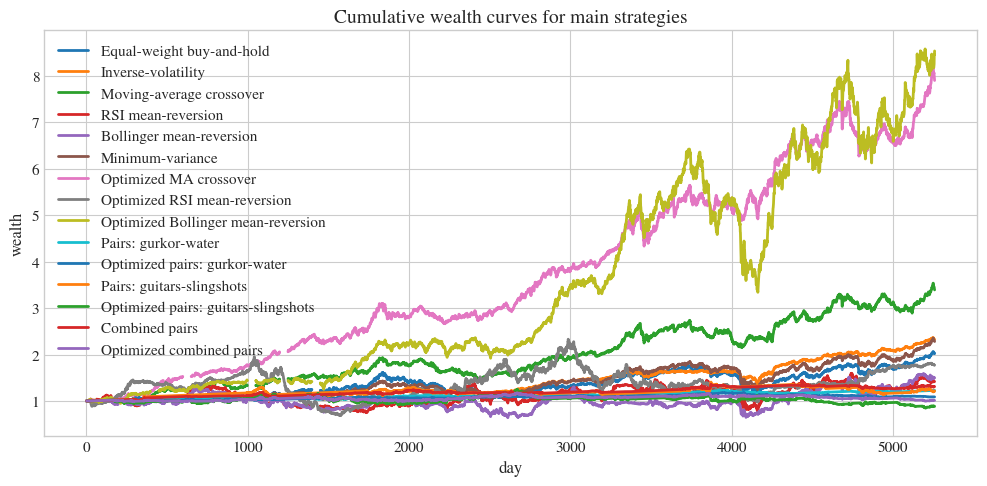

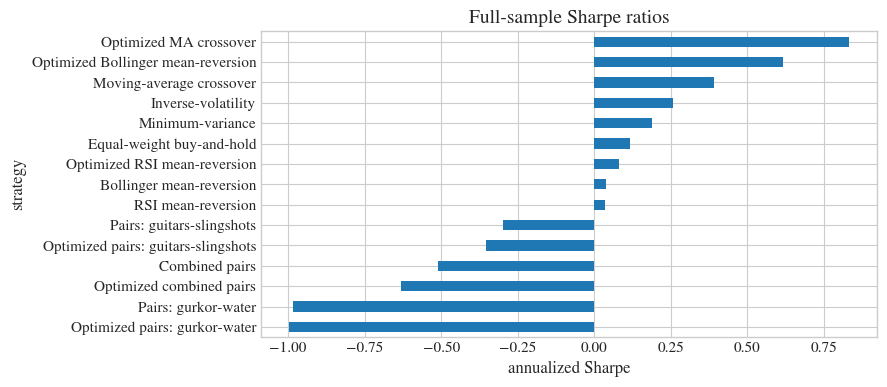

In [12]:
wealth = pd.DataFrame({name: cumulative_wealth(main_returns[name]) for name in main_returns.columns})
fig, ax = plt.subplots(figsize=(10, 5))
wealth.rename(columns=STRATEGY_LABELS).plot(ax=ax)
ax.set_title("Cumulative wealth curves for main strategies")
ax.set_ylabel("wealth")
ax.set_xlabel("day")
fig.tight_layout()
fig.savefig(fig_dir / "task4_validation_cumulative_wealth.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
full_performance["sharpe"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Full-sample Sharpe ratios")
ax.set_xlabel("annualized Sharpe")
fig.tight_layout()
fig.savefig(fig_dir / "task4_validation_sharpe_bar.png", dpi=300, bbox_inches="tight")
plt.show()

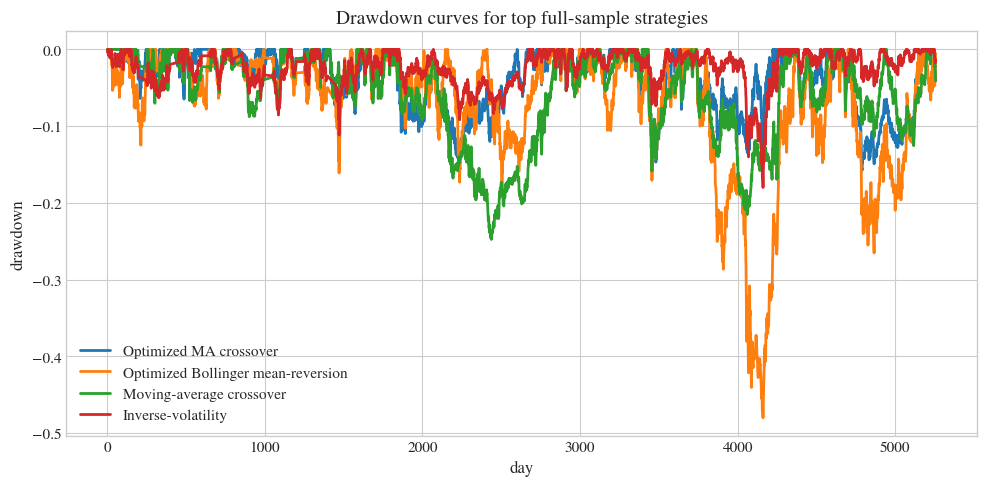

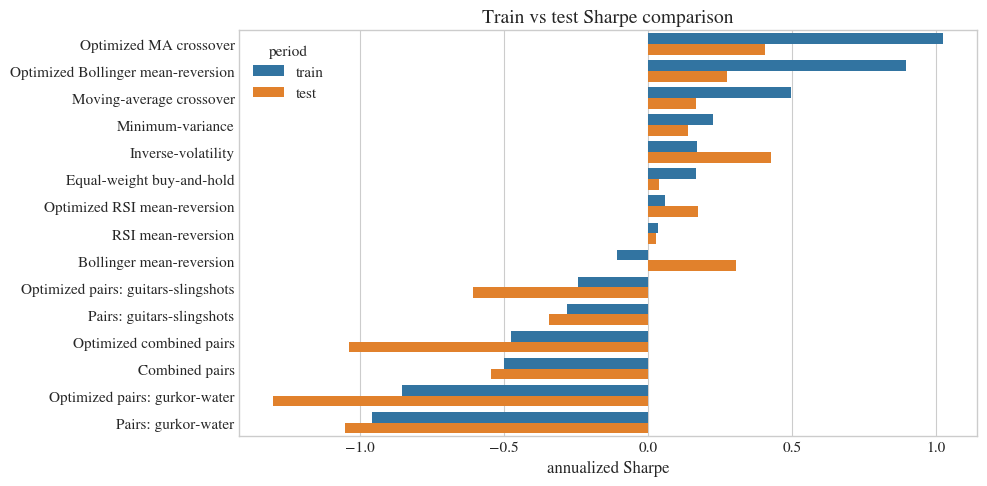

In [13]:
top_strategies = full_performance.head(4).index.tolist()
label_to_key = {v: k for k, v in STRATEGY_LABELS.items()}
fig, ax = plt.subplots(figsize=(10, 5))
for label in top_strategies:
    key = label_to_key[label]
    dd = cumulative_wealth(main_returns[key])
    dd = dd / dd.cummax() - 1
    ax.plot(dd.index, dd.values, label=label)
ax.set_title("Drawdown curves for top full-sample strategies")
ax.set_ylabel("drawdown")
ax.set_xlabel("day")
ax.legend()
fig.tight_layout()
fig.savefig(fig_dir / "task4_validation_top_drawdowns.png", dpi=300, bbox_inches="tight")
plt.show()

plot_tt = train_test_table.reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_tt, x="sharpe", y="strategy", hue="period", ax=ax)
ax.set_title("Train vs test Sharpe comparison")
ax.set_xlabel("annualized Sharpe")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(fig_dir / "task4_validation_train_test_sharpe.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Walk-forward validation

Walk-forward validation repeatedly chooses parameters using only an in-sample window and evaluates the selected parameters on the next out-of-sample block. This approximates how a strategy would be recalibrated in production. Stable parameter choices and consistent out-of-sample Sharpe ratios are stronger evidence than one high full-sample Sharpe.

In [14]:
FAST_WINDOWS = [10, 20, 30, 50]
SLOW_WINDOWS = [50, 100, 150, 200]
MA_GRID = [{"fast": f, "slow": s} for f, s in product(FAST_WINDOWS, SLOW_WINDOWS) if f < s]
RSI_GRID = [{"window": w, "entry": 30, "exit_threshold": e} for w, e in product([10, 14, 21], [50, 70])]
BOLL_GRID = [{"window": w, "multiplier": m} for w, m in product([20, 50, 100], [1.5, 2.0, 2.5])]
PAIR_GRID = [{"window": w, "entry_z": e, "exit_z": x} for w, e, x in product([126, 252], [1.5, 2.0, 2.5], [0.5, 1.0]) if x < e]


def parameterized_weights(strategy: str, params: dict) -> pd.DataFrame:
    if strategy == "ma_crossover":
        return moving_average_crossover(prices, **params)
    if strategy == "rsi_reversion":
        return rsi_mean_reversion(prices, **params)
    if strategy == "bollinger_reversion":
        return bollinger_mean_reversion(prices, **params)
    if strategy == "pairs_combined":
        pair_frames = []
        for pair in PAIRS:
            w, _, _ = pairs_trading_weights(log_prices, pair, **params)
            pair_frames.append(w.fillna(0.0))
        return sum(pair_frames) / len(pair_frames)
    raise ValueError(strategy)


def fold_indices(index: pd.Index, train_len: int = 1000, test_len: int = 252, step: int = 252) -> list[tuple[pd.Index, pd.Index]]:
    folds = []
    max_start = len(index) - train_len - test_len
    for start in range(0, max_start + 1, step):
        train_idx = index[start: start + train_len]
        test_idx = index[start + train_len: start + train_len + test_len]
        if len(train_idx) == train_len and len(test_idx) == test_len:
            folds.append((train_idx, test_idx))
    return folds


def walk_forward(strategy: str, grid: list[dict], index: pd.Index) -> pd.DataFrame:
    rows = []
    folds = fold_indices(index)
    cache = {}
    for fold_no, (train_idx, test_idx) in enumerate(folds, start=1):
        best_params = None
        best_sharpe = -np.inf
        best_returns = None
        best_weights = None
        for params in grid:
            key = tuple(sorted(params.items()))
            if key not in cache:
                w = parameterized_weights(strategy, params)
                r = portfolio_returns(w, simple_returns)
                cache[key] = (w, r)
            w, r = cache[key]
            train_sharpe = sharpe_ratio(r.reindex(train_idx))
            if pd.notna(train_sharpe) and train_sharpe > best_sharpe:
                best_sharpe = train_sharpe
                best_params = params
                best_returns = r
                best_weights = w
        if best_params is None:
            continue
        test_r = best_returns.reindex(test_idx)
        rows.append({
            "strategy": strategy,
            "fold": fold_no,
            "train_start": int(train_idx.min()),
            "train_end": int(train_idx.max()),
            "test_start": int(test_idx.min()),
            "test_end": int(test_idx.max()),
            "train_sharpe": best_sharpe,
            "test_sharpe": sharpe_ratio(test_r),
            "test_max_drawdown": max_drawdown(test_r),
            "test_turnover": strategy_turnover(best_weights.reindex(test_idx)),
            "params": str(best_params),
            **{f"param_{k}": v for k, v in best_params.items()},
        })
    return pd.DataFrame(rows)

wf_results = pd.concat(
    [
        walk_forward("ma_crossover", MA_GRID, historical_index),
        walk_forward("rsi_reversion", RSI_GRID, historical_index),
        walk_forward("bollinger_reversion", BOLL_GRID, historical_index),
        walk_forward("pairs_combined", PAIR_GRID, historical_index),
    ],
    ignore_index=True,
)

wf_summary = (
    wf_results
    .groupby("strategy")
    .agg(
        folds=("fold", "count"),
        mean_oos_sharpe=("test_sharpe", "mean"),
        median_oos_sharpe=("test_sharpe", "median"),
        mean_oos_drawdown=("test_max_drawdown", "mean"),
        mean_oos_turnover=("test_turnover", "mean"),
    )
)
wf_summary.index = wf_summary.index.map(STRATEGY_LABELS)
write_latex_table(wf_summary, table_dir / "task4_validation_walk_forward.tex", float_format="%.4f")
wf_summary

,folds,mean_oos_sharpe,median_oos_sharpe,mean_oos_drawdown,mean_oos_turnover
strategy,,,,,
Bollinger mean-reversion,16,0.278673,0.239343,-0.185121,0.100182
Moving-average crossover,16,0.355965,0.190905,-0.084050,0.060380
Combined pairs,16,-0.619131,-0.521767,-0.015774,0.006069
RSI mean-reversion,16,0.113363,0.035904,-0.187965,0.077521


In [15]:
param_rows = []
for strategy, group in wf_results.groupby("strategy"):
    param_cols = [c for c in group.columns if c.startswith("param_")]
    for col in param_cols:
        counts = group[col].value_counts(dropna=True)
        for value, count in counts.items():
            param_rows.append({
                "strategy": STRATEGY_LABELS.get(strategy, strategy),
                "parameter": col.replace("param_", ""),
                "value": value,
                "fold_count": int(count),
                "share_of_folds": count / len(group),
            })
parameter_stability = pd.DataFrame(param_rows)
write_latex_table(parameter_stability, table_dir / "task4_validation_parameter_stability.tex", float_format="%.4f", index=False)
parameter_stability.head(20)

,strategy,parameter,value,fold_count,share_of_folds
0,Bollinger mean-reversion,window,20.0,10,0.6250
1,Bollinger mean-reversion,window,50.0,6,0.3750
2,Bollinger mean-reversion,multiplier,2.5,9,0.5625
3,Bollinger mean-reversion,multiplier,1.5,4,0.2500
4,Bollinger mean-reversion,multiplier,2.0,3,0.1875
5,Moving-average crossover,fast,10.0,10,0.6250
6,Moving-average crossover,fast,30.0,4,0.2500
7,Moving-average crossover,fast,20.0,2,0.1250
8,Moving-average crossover,slow,50.0,8,0.5000
9,Moving-average crossover,slow,100.0,6,0.3750


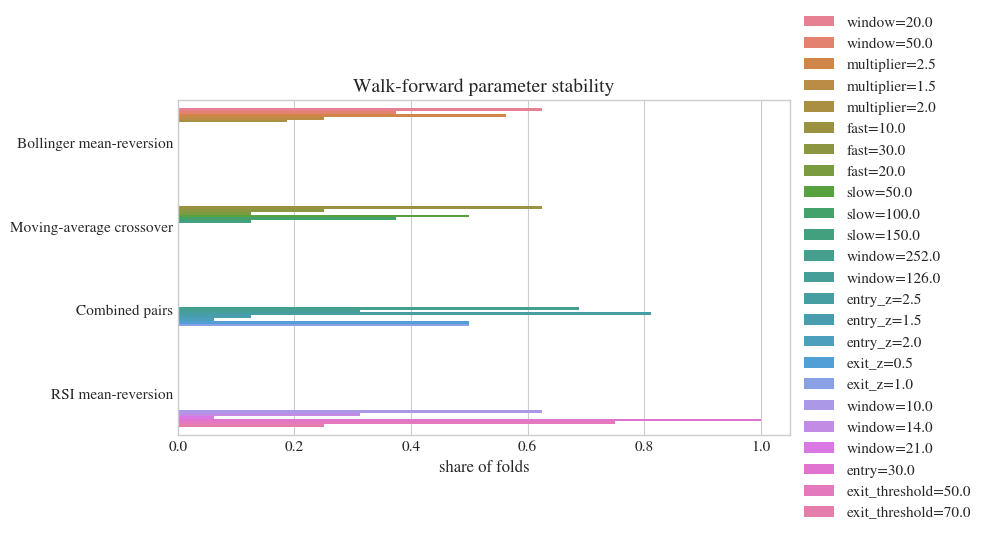

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
if not parameter_stability.empty:
    plot_stability = parameter_stability.copy()
    plot_stability["parameter_value"] = plot_stability["parameter"] + "=" + plot_stability["value"].astype(str)
    sns.barplot(data=plot_stability, x="share_of_folds", y="strategy", hue="parameter_value", ax=ax)
    ax.set_title("Walk-forward parameter stability")
    ax.set_xlabel("share of folds")
    ax.set_ylabel("")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
else:
    ax.text(0.5, 0.5, "No parameter stability data", ha="center", va="center")
fig.tight_layout()
fig.savefig(fig_dir / "task4_validation_parameter_stability.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Pairs trading diagnostics

Pairs trading uses log-price spreads and rolling hedge ratios. An ADF test is reported for the estimated spread when available: lower p-values are more consistent with mean reversion, although the rolling hedge-ratio construction means this is only a diagnostic, not a proof that the strategy will work in production.

In [17]:
pair_rows = []
for pair in PAIRS:
    key = f"pairs_{pair[0]}_{pair[1]}"
    spread = pair_spreads[key].dropna()
    z = pair_zscores[key]
    pair_return = main_returns[key]
    adf_stat = np.nan
    adf_pvalue = np.nan
    if adfuller is not None and len(spread) > 50:
        try:
            adf_result = adfuller(spread.dropna(), autolag="AIC")
            adf_stat = adf_result[0]
            adf_pvalue = adf_result[1]
        except Exception:
            pass
    pair_rows.append({
        "pair": f"{pair[0]}-{pair[1]}",
        "adf_stat": adf_stat,
        "adf_pvalue": adf_pvalue,
        "sharpe": sharpe_ratio(pair_return),
        "max_drawdown": max_drawdown(pair_return),
        "observed_days": int(pair_return.notna().sum()),
        "mean_abs_zscore": z.abs().mean(),
    })

pairs_results = pd.DataFrame(pair_rows).set_index("pair")
write_latex_table(pairs_results, table_dir / "task4_validation_pairs_results.tex", float_format="%.4f")
pairs_results

,adf_stat,adf_pvalue,sharpe,max_drawdown,observed_days,mean_abs_zscore
pair,,,,,,
gurkor-water,-6.097973,9.993648e-08,-0.984885,-0.060752,5194,1.275978
guitars-slingshots,-6.418923,1.811882e-08,-0.299720,-0.188163,5245,1.271829


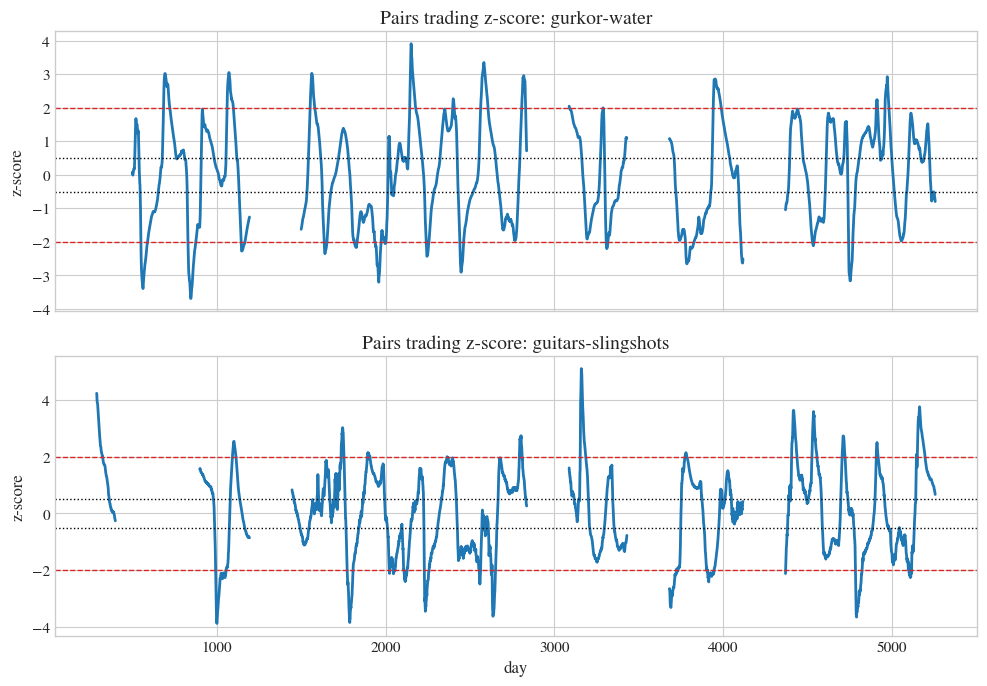

In [18]:
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(10, 3.5 * len(PAIRS)), sharex=True)
if len(PAIRS) == 1:
    axes = [axes]
for ax, pair in zip(axes, PAIRS):
    key = f"pairs_{pair[0]}_{pair[1]}"
    z = pair_zscores[key]
    ax.plot(z.index, z.values, label="spread z-score")
    ax.axhline(2, color="tab:red", linestyle="--", linewidth=1)
    ax.axhline(-2, color="tab:red", linestyle="--", linewidth=1)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1)
    ax.axhline(-0.5, color="black", linestyle=":", linewidth=1)
    ax.set_title(f"Pairs trading z-score: {pair[0]}-{pair[1]}")
    ax.set_ylabel("z-score")
axes[-1].set_xlabel("day")
fig.tight_layout()
fig.savefig(fig_dir / "task4_validation_pairs_zscores.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Bootstrap Sharpe uncertainty

Daily returns are resampled with replacement to estimate the uncertainty around each Sharpe ratio. This simple bootstrap ignores serial dependence, so it is best interpreted as a first-order uncertainty check rather than a full distributional model.

In [19]:
def bootstrap_sharpe(returns: pd.Series, n_boot: int = BOOTSTRAP_SAMPLES, seed: int = RNG_SEED) -> dict[str, float]:
    clean = returns.dropna().to_numpy()
    if len(clean) < 5:
        return {"estimated_sharpe": np.nan, "sharpe_5pct": np.nan, "sharpe_95pct": np.nan, "prob_sharpe_gt_0": np.nan}
    rng = np.random.default_rng(seed)
    draws = rng.choice(clean, size=(n_boot, len(clean)), replace=True)
    daily_rf = DAILY_RF
    excess = draws - daily_rf
    boot = excess.mean(axis=1) / excess.std(axis=1, ddof=1) * np.sqrt(TRADING_DAYS)
    return {
        "estimated_sharpe": sharpe_ratio(returns),
        "sharpe_5pct": float(np.quantile(boot, 0.05)),
        "sharpe_95pct": float(np.quantile(boot, 0.95)),
        "prob_sharpe_gt_0": float(np.mean(boot > 0)),
    }

bootstrap_table = pd.DataFrame({
    STRATEGY_LABELS.get(name, name): bootstrap_sharpe(main_returns[name], seed=RNG_SEED + i)
    for i, name in enumerate(main_returns.columns)
}).T.sort_values("estimated_sharpe", ascending=False)
write_latex_table(bootstrap_table, table_dir / "task4_validation_bootstrap_sharpe.tex", float_format="%.4f")
bootstrap_table

,estimated_sharpe,sharpe_5pct,sharpe_95pct,prob_sharpe_gt_0
Optimized MA crossover,0.831795,0.467067,1.200349,1.000
Optimized Bollinger mean-reversion,0.616562,0.254550,0.988576,1.000
Moving-average crossover,0.389904,0.020228,0.761454,0.956
Inverse-volatility,0.258446,-0.098604,0.643684,0.865
Minimum-variance,0.189878,-0.190460,0.577249,0.821
Equal-weight buy-and-hold,0.117438,-0.264260,0.486002,0.704
Optimized RSI mean-reversion,0.081575,-0.267183,0.426563,0.639
Bollinger mean-reversion,0.038673,-0.336033,0.378719,0.538
RSI mean-reversion,0.033363,-0.325262,0.400545,0.571
Pairs: guitars-slingshots,-0.299720,-0.652208,0.077895,0.100


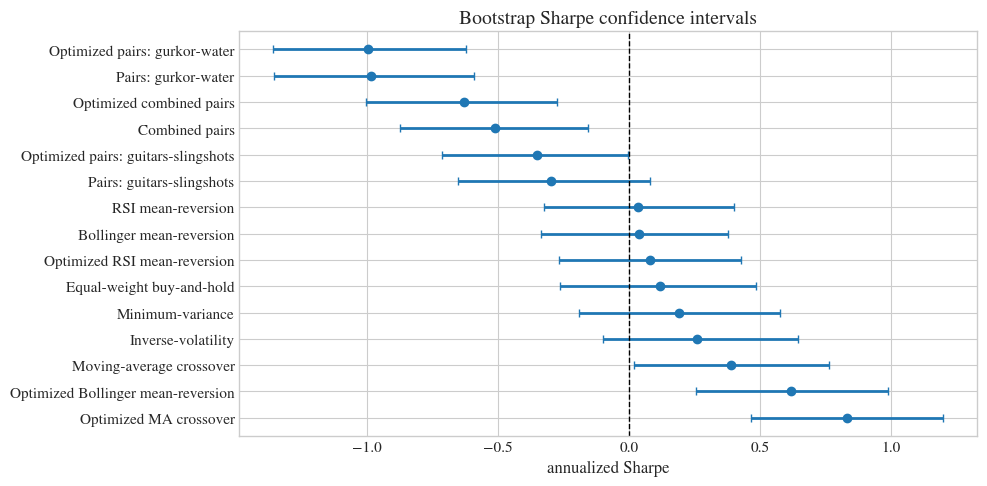

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_boot = bootstrap_table.reset_index().rename(columns={"index": "strategy"})
y = np.arange(len(plot_boot))
ax.errorbar(
    plot_boot["estimated_sharpe"],
    y,
    xerr=[plot_boot["estimated_sharpe"] - plot_boot["sharpe_5pct"], plot_boot["sharpe_95pct"] - plot_boot["estimated_sharpe"]],
    fmt="o",
    capsize=3,
)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(plot_boot["strategy"])
ax.set_title("Bootstrap Sharpe confidence intervals")
ax.set_xlabel("annualized Sharpe")
fig.tight_layout()
fig.savefig(fig_dir / "task4_validation_bootstrap_sharpe.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Production recommendation

The final ranking below emphasizes production credibility rather than Sharpe ratio alone. A credible strategy should have positive out-of-sample evidence, manageable drawdown, moderate turnover, interpretable logic, and bootstrap support that its Sharpe is likely above zero. Strategies with high in-sample Sharpe but weak test or walk-forward performance are treated as overfit candidates.

In [21]:
recommendation = full_performance.copy()
recommendation["test_sharpe"] = test_performance["sharpe"]
recommendation["bootstrap_prob_sharpe_gt_0"] = bootstrap_table["prob_sharpe_gt_0"]
recommendation["credibility_score"] = (
    recommendation["test_sharpe"].fillna(-5).rank(pct=True)
    + recommendation["sharpe"].fillna(-5).rank(pct=True)
    + recommendation["bootstrap_prob_sharpe_gt_0"].fillna(0).rank(pct=True)
    + (-recommendation["max_drawdown"].abs()).rank(pct=True)
    + (-recommendation["turnover"]).rank(pct=True)
)
recommendation = recommendation.sort_values("credibility_score", ascending=False)
write_latex_table(recommendation, table_dir / "task4_validation_production_ranking.tex", float_format="%.4f")
recommendation[["sharpe", "test_sharpe", "max_drawdown", "turnover", "bootstrap_prob_sharpe_gt_0", "credibility_score"]]

,sharpe,test_sharpe,max_drawdown,turnover,bootstrap_prob_sharpe_gt_0,credibility_score
strategy,,,,,,
Inverse-volatility,0.258446,0.428172,-0.179900,0.003665,0.865,4.200000
Optimized MA crossover,0.831795,0.406968,-0.158425,0.027220,1.000,4.166667
Minimum-variance,0.189878,0.140051,-0.327563,0.000183,0.821,3.466667
Moving-average crossover,0.389904,0.167976,-0.247605,0.035606,0.956,3.266667
Optimized Bollinger mean-reversion,0.616562,0.272266,-0.479930,0.052456,1.000,3.100000
Equal-weight buy-and-hold,0.117438,0.037854,-0.372426,0.006913,0.704,3.066667
Optimized RSI mean-reversion,0.081575,0.173326,-0.649152,0.015396,0.639,2.600000
Pairs: guitars-slingshots,-0.299720,-0.343457,-0.188163,0.010945,0.100,2.533333
Combined pairs,-0.511116,-0.544552,-0.074571,0.011241,0.010,2.466667


## 11. Production recommendation and conclusions

The credibility score in Section 10 combines test Sharpe, full-sample Sharpe, bootstrap Sharpe support, maximum drawdown, and turnover. The main findings are:

- **Ranking by full-sample Sharpe alone overstates reliability.** Optimised MA crossover has the highest full-sample Sharpe (≈ 0.83), but its test-period Sharpe (≈ 0.41) is lower. The production ranking penalises this in-sample advantage.
- **Inverse-volatility tops the credibility ranking** because its test-period Sharpe (≈ 0.43) exceeds its train-period value, its drawdown is modest (−18%), and its daily turnover is very low (< 0.4%). It directly exploits the large volatility differences across assets that Task 1 documented.
- **Pairs trading underperforms despite statistical evidence of mean reversion.** Both pairs show highly significant ADF statistics ($p < 10^{-7}$), but their Sharpe ratios are negative. A stationary spread is necessary but not sufficient for profitable spread trading: the z-score must also cross entry thresholds frequently enough to generate useful signals.
- **Walk-forward validation confirms trend-following edge.** MA crossover and Bollinger reversion show positive mean out-of-sample Sharpe across 16 walk-forward folds, which is more robust evidence than full-sample Sharpe alone.
- **Bootstrap Sharpe intervals quantify uncertainty.** Only optimised MA crossover and optimised Bollinger reversion have 5th-percentile bootstrap Sharpe above zero; all others have plausible Sharpe of zero or below.

For the report, discuss the top-ranked strategy as the main production candidate, compare it against the equal-weight buy-and-hold baseline, and note explicitly that all historical evidence comes from observed prices only.

## 12. Forward scenario analysis using Task 3 simulated paths

This section applies the same strategy rules to Task 3 future-price scenarios. These are not realised historical returns. Each scenario is a single simulated path produced by a GARCH model, and strategy signals respond to those simulated prices exactly as they would to real prices. The performance numbers are **scenario-conditional expectations**, not backtests.

If Task 3 exported full simulated paths (`task3_joint_simulated_price_paths.npz`), all paths are used as separate scenarios. If only the forecast summary CSV is available, four deterministic scenarios are constructed: mean, median, lower 90%, and upper 90%.

In [ ]:
def load_task3_scenarios() -> tuple[dict[str, pd.DataFrame], str]:
    scenario_files = [
        repo_root / "Output" / "task3" / "task3_joint_simulated_price_paths.npz",
        repo_root / "Output" / "task3" / "task3_simulated_price_paths.npz",
    ]
    for path in scenario_files:
        if path.exists():
            data = np.load(path)
            days = data["days"]
            paths = data["paths"]
            scenarios = {}
            for i in range(paths.shape[0]):
                scenarios[f"sim_{i + 1:04d}"] = pd.DataFrame(paths[i], index=days, columns=ASSETS)
            return scenarios, f"loaded simulated Task 3 paths from {path.relative_to(repo_root)}"

    forecast_path = repo_root / "Output" / "task3" / "task3_terminal_forecasts.csv"
    if not forecast_path.exists():
        return {}, "no Task 3 forecast or simulated path file found"

    forecasts = pd.read_csv(forecast_path)
    method = "joint_garch_corr_t" if "joint_garch_corr_t" in forecasts["method"].unique() else forecasts["method"].iloc[-1]
    f = forecasts[forecasts["method"] == method]

    scenario_columns = {
        "mean_path": "price_mean",
        "median_path": "price_median",
        "lower_90_path": "price_lower_90" if "price_lower_90" in f.columns else "price_lower_95",
        "upper_90_path": "price_upper_90" if "price_upper_90" in f.columns else "price_upper_95",
    }
    scenarios = {}
    for scenario_name, price_col in scenario_columns.items():
        scenarios[scenario_name] = f.pivot(index="day", columns="asset", values=price_col).reindex(columns=ASSETS)
    return scenarios, f"built forecast-summary scenarios from {forecast_path.relative_to(repo_root)} using {method}"


future_scenarios, scenario_source = load_task3_scenarios()
print(scenario_source)
print(f"Number of forward scenarios: {len(future_scenarios)}")
list(future_scenarios)[:5]

In [ ]:
def scenario_strategy_returns(future_prices: pd.DataFrame, base_prices: pd.DataFrame, base_weights: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    future_start = int(future_prices.index.min())
    historical_prices = base_prices.loc[: future_start - 1]
    historical_log_returns = np.log(historical_prices).diff()
    last_observed = historical_prices.ffill().tail(1)
    stitched = pd.concat([last_observed, future_prices])
    future_simple_returns = stitched.pct_change(fill_method=None).iloc[1:]
    future_log_returns = np.log(stitched).diff().iloc[1:]

    scenario_returns = {}
    scenario_weights = {}
    for name, hist_weights in base_weights.items():
        last_position = positions_from_signals(hist_weights.loc[: future_start - 1], simple_returns.loc[: future_start - 1]).ffill().tail(1)
        future_target = pd.DataFrame(np.nan, index=future_simple_returns.index, columns=ASSETS)
        if not last_position.empty:
            future_target.iloc[0] = last_position.iloc[0]

        if name == "inverse_volatility":
            combined_log = pd.concat([historical_log_returns, future_log_returns])
            future_target.update(inverse_volatility_weights(combined_log).loc[future_simple_returns.index])
        elif name == "time_series_momentum":
            combined_log = pd.concat([historical_log_returns, future_log_returns])
            future_target.update(time_series_momentum_weights(combined_log).loc[future_simple_returns.index])
        elif name == "cross_sectional_momentum":
            combined_log = pd.concat([historical_log_returns, future_log_returns])
            future_target.update(cross_sectional_momentum_weights(combined_log).loc[future_simple_returns.index])
        elif name == "moving_average_trend":
            combined_prices = pd.concat([historical_prices, future_prices])
            future_target.update(moving_average_trend_weights(combined_prices).loc[future_simple_returns.index])
        elif name == "buy_dips_reversal":
            combined_log = pd.concat([historical_log_returns, future_log_returns])
            future_target.update(buy_dips_reversal_weights(combined_log).loc[future_simple_returns.index])
        elif name == "equal_weight_rebalanced":
            future_target.update(equal_weight_monthly_rebalanced_weights(future_simple_returns))
        elif name == "equal_weight_buy_hold":
            future_target.update(equal_weight_buy_hold_weights(future_simple_returns))

        scenario_weights[name] = future_target
        scenario_returns[name] = portfolio_returns_from_positions(future_target, future_simple_returns)

    return pd.DataFrame(scenario_returns), scenario_weights


scenario_rows = []
scenario_value_panels = {}
for scenario_name, future_prices in future_scenarios.items():
    scen_returns, scen_weights = scenario_strategy_returns(future_prices, prices, main_weights)
    scen_values = (1 + scen_returns.fillna(0)).cumprod() * INITIAL_CAPITAL
    scenario_value_panels[scenario_name] = scen_values
    scenario_simple_returns = future_prices.pct_change(fill_method=None)
    for strategy in scen_returns.columns:
        metrics = performance_metrics(scen_returns[strategy], scen_weights[strategy], scenario_simple_returns)
        metrics.update({"scenario": scenario_name, "strategy": METHOD_LABELS[strategy]})
        scenario_rows.append(metrics)

scenario_performance = pd.DataFrame(scenario_rows)
if not scenario_performance.empty:
    scenario_performance = scenario_performance.set_index(["scenario", "strategy"])
    write_latex_table(scenario_performance, table_dir / "task4_forward_scenario_performance.tex", float_format="%.4f")
scenario_performance

In [ ]:
def scenario_strategy_returns(future_prices: pd.DataFrame, base_prices: pd.DataFrame, base_weights: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    future_start = int(future_prices.index.min())
    historical_prices = base_prices.loc[: future_start - 1]
    historical_log_returns = np.log(historical_prices).diff()
    last_observed = historical_prices.ffill().tail(1)
    stitched = pd.concat([last_observed, future_prices])
    future_simple_returns = stitched.pct_change(fill_method=None).iloc[1:]
    future_log_returns = np.log(stitched).diff().iloc[1:]

    scenario_returns = {}
    scenario_weights = {}
    for name, hist_weights in base_weights.items():
        last_position = positions_from_signals(hist_weights.loc[: future_start - 1], simple_returns.loc[: future_start - 1]).ffill().tail(1)
        future_target = pd.DataFrame(np.nan, index=future_simple_returns.index, columns=ASSETS)
        if not last_position.empty:
            future_target.iloc[0] = last_position.iloc[0]

        if name == "inverse_volatility":
            combined_log = pd.concat([historical_log_returns, future_log_returns])
            future_target.update(inverse_volatility_weights(combined_log).loc[future_simple_returns.index])
        elif name == "time_series_momentum":
            combined_log = pd.concat([historical_log_returns, future_log_returns])
            future_target.update(time_series_momentum_weights(combined_log).loc[future_simple_returns.index])
        elif name == "cross_sectional_momentum":
            combined_log = pd.concat([historical_log_returns, future_log_returns])
            future_target.update(cross_sectional_momentum_weights(combined_log).loc[future_simple_returns.index])
        elif name == "moving_average_trend":
            combined_prices = pd.concat([historical_prices, future_prices])
            future_target.update(moving_average_trend_weights(combined_prices).loc[future_simple_returns.index])
        elif name == "buy_dips_reversal":
            combined_log = pd.concat([historical_log_returns, future_log_returns])
            future_target.update(buy_dips_reversal_weights(combined_log).loc[future_simple_returns.index])
        elif name == "equal_weight_rebalanced":
            future_target.update(equal_weight_monthly_rebalanced_weights(future_simple_returns))
        elif name == "equal_weight_buy_hold":
            future_target.update(equal_weight_buy_hold_weights(future_simple_returns))

        scenario_weights[name] = future_target
        scenario_returns[name] = portfolio_returns_from_positions(future_target, future_simple_returns)

    return pd.DataFrame(scenario_returns), scenario_weights


scenario_rows = []
scenario_value_panels = {}
for scenario_name, future_prices in future_scenarios.items():
    scen_returns, scen_weights = scenario_strategy_returns(future_prices, prices, main_weights)
    scen_values = (1 + scen_returns.fillna(0)).cumprod() * INITIAL_CAPITAL
    scenario_value_panels[scenario_name] = scen_values
    scenario_simple_returns = future_prices.pct_change(fill_method=None)
    for strategy in scen_returns.columns:
        metrics = performance_metrics(scen_returns[strategy], scen_weights[strategy], scenario_simple_returns)
        metrics.update({"scenario": scenario_name, "strategy": METHOD_LABELS[strategy]})
        scenario_rows.append(metrics)

scenario_performance = pd.DataFrame(scenario_rows)
if not scenario_performance.empty:
    scenario_performance = scenario_performance.set_index(["scenario", "strategy"])
    write_latex_table(scenario_performance, table_dir / "task4_forward_scenario_performance.tex", float_format="%.4f")
scenario_performance

In [ ]:
if scenario_value_panels:
    first_scenario = next(iter(scenario_value_panels))
    fig, ax = plt.subplots(figsize=(10, 5))
    scenario_value_panels[first_scenario].rename(columns=METHOD_LABELS).plot(ax=ax)
    ax.set_title(f"Forward scenario portfolio values: {first_scenario}")
    ax.set_ylabel("simulated value of 1 initial unit")
    ax.set_xlabel("future day")
    fig.tight_layout()
    fig.savefig(fig_dir / "task4_forward_scenario_portfolio_values.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No forward scenarios available to plot.")

Historical and forward-scenario performance should be discussed separately in the report. The historical Sharpe ratios come from observed prices; the forward-scenario Sharpe ratios are conditional on a specific simulated future path. Neither number is a guarantee of future performance.

If multiple simulated paths are available, the distribution of forward-scenario Sharpe ratios gives a richer picture of strategy robustness than any single scenario. Strategies that perform well across most paths are more credible than those that dominate only under specific price trajectories.